In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import copy
from itertools import product
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import auc

import col_fitting_xc
import rapa_fitting
import single_drug_fitting
import tx_fitting
from rebinding.fig_utils import defaultStyle, save_fig

defaultStyle(fs=14)

# Rebinding quantification

In [15]:
drugs_short = [
    "PTX",
    "DTX",
    "Rapa",
    "Trm",
    "Slm",
    "Col",
    "CA4",
    "VB",
    "Ixa",
    "Ali",
    "Isp",
    "Erlo",
    "Top",
]

drugs = [
    "PTX",
    "DTX",
    "Rapamycin",
    "Trametinib",
    "Selumetinib",
    "Colchicine",
    "CA4",
    "VB",
    "Ixazomib",
    "Alisertib",
    "Ispinesib",
    "Erlotinib",
    "Topotecan",
]


def auc_ratio(y_data_1, y_data_2, t_eval):
    y_data_1 = y_data_1.mean(axis=0)
    y_data_2 = y_data_2.mean(axis=0)
    y_min = np.min([y_data_1.min(), y_data_2.min()])
    auc_ratio = auc(t_eval, (y_data_1 - y_min)) / auc(t_eval, (y_data_2 - y_min))
    return auc_ratio


def max_fold_change(y_data_1, y_data_2):
    y_data_1 /= y_data_1[:, 0].mean()
    y_data_2 /= y_data_2[:, 0].mean()
    mean_ratios = np.log10(y_data_1.mean(axis=0) / y_data_2.mean(axis=0))
    max_idx = np.argmax(mean_ratios)
    max_ratios = []
    for x, y in product(y_data_1[:, max_idx], y_data_2[:, max_idx]):
        max_ratios.append(np.log10(x / y))
    return mean_ratios[max_idx], np.std(max_ratios)


frb = {}
auc_ratios = {}
flag = False
for i, drug in enumerate(drugs):
    if drug == "PTX":
        y_data_1, y_data_2, t_eval = tx_fitting.load_multi_wash_data()[:3]
        t_eval = t_eval[0]
    elif drug == "Rapamycin":
        _, y_data_1, _, y_data_2, t_eval = rapa_fitting.load_rapa_washout_data()[:5]
    elif drug == "Colchicine":
        (
            y_data_1,
            y_data_2,
            y_data_3,
            y_data_4,
            t_eval,
        ) = col_fitting_xc.load_washout_data()[:5]
        flag = True
        frb[drugs[i + 1]] = max_fold_change(y_data_3, y_data_4)
        auc_ratios[drugs[i + 1]] = auc_ratio(y_data_3, y_data_4, t_eval)
    elif drug == "CA4":
        continue
    else:
        y_data_1, y_data_2, t_eval = single_drug_fitting.load_washout_data(
            drugs_short[i]
        )[:3]
    frb[drug] = max_fold_change(y_data_1, y_data_2)
    auc_ratios[drug] = auc_ratio(y_data_1, y_data_2, t_eval)

In [17]:
params_true_df = pd.read_csv("../data/Compounds_params_ground_truth_filt.csv")[
    ["Drug", "koff", "kd", "target", "plasma_binding", "LogP"]
]
params_true_df.target *= 10
params_true_df = params_true_df.iloc[:-2]
params_true_df["frb"] = params_true_df.Drug.apply(lambda s: frb[s][0])
params_true_df["auc_ratio"] = params_true_df.Drug.apply(lambda s: auc_ratios[s])
params_true_df["frb_std"] = params_true_df.Drug.apply(lambda s: frb[s][1])
params_true_df["rinv_true"] = params_true_df.target / params_true_df.kd
params_true_df["logrinv_true"] = params_true_df.rinv_true.apply(np.log10)
params_true_df

,Drug,koff,kd,target,plasma_binding,LogP,frb,auc_ratio,frb_std,rinv_true,logrinv_true
0,PTX,0.091000,5.00,10.000000,95.0,3.20,1.571889,8.305509,0.376902,2.000000,0.301030
1,DTX,0.045500,2.50,10.000000,97.0,2.59,0.736099,6.646466,0.007754,4.000000,0.602060
2,Colchicine,0.000029,24.00,10.000000,39.0,1.59,0.542936,1.582762,0.052414,0.416667,-0.380211
3,CA4,0.003200,140.00,10.000000,72.3,3.32,0.931332,1.867982,0.042960,0.071429,-1.146128
4,VB,0.008200,160.00,10.000000,98.9,4.22,0.198870,1.073377,0.025229,0.062500,-1.204120
5,Alisertib,0.000233,0.27,0.043546,99.0,5.00,0.445708,1.333335,0.136363,0.161283,-0.792411
6,Ispinesib,0.000005,10.00,0.153247,99.4,4.71,0.052495,1.266534,0.019478,0.015325,-1.814609
7,Rapamycin,0.001160,0.20,1.853693,92.0,4.85,2.476342,3.337504,0.125940,9.268466,0.967008
8,Trametinib,0.000120,0.35,0.741477,97.4,3.45,0.647633,1.623833,0.029212,2.118506,0.326030
9,Selumetinib,0.010000,99.00,0.286932,98.4,3.24,0.423325,1.365856,0.147784,0.002898,-2.537856


0.7582417582417583 0.0026660786121372876
Saving figure fig4-fold-change-vs-r


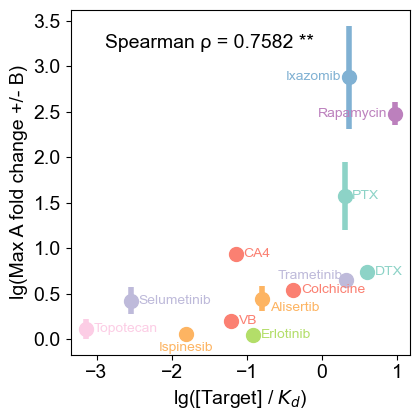

In [18]:
set3_colors = mpl.colormaps["Set3"]
colors = [
    set3_colors(0),
    set3_colors(0),
    set3_colors(9),
    set3_colors(2),
    set3_colors(2),
    set3_colors(3),
    set3_colors(3),
    set3_colors(3),
    set3_colors(4),
    set3_colors(5),
    set3_colors(5),
    set3_colors(6),
    set3_colors(7),
]

_, ax = plt.subplots(figsize=(4.3, 4.3))
for i, drug in enumerate(drugs):
    df = params_true_df[params_true_df.Drug == drug]
    ax.errorbar(
        x=df.logrinv_true,
        y=df.frb,
        yerr=df.frb_std,
        color=colors[i],
        linestyle="",
        marker="o",
        linewidth=4,
        markersize=10,
    )
    x = df.logrinv_true.values[0]
    y = df.frb.values[0]
    if drug == "Ispinesib": 
        ax.text(x, y - 0.15, drug, color=colors[i], ha="center", va="center")
    elif drug in ["Rapamycin", "Ixazomib"]:
        ax.text(x - 0.1, y, drug, color=colors[i], ha="right", va="center")
    elif drug == "Alisertib":
        ax.text(x + 0.1, y - 0.1, drug, color=colors[i], ha="left", va="center")
    elif drug == "Trametinib": 
        ax.text(x - 0.05, y + 0.05, drug, color=colors[i], ha="right", va="center")
    else:
        ax.text(x + 0.1, y, drug, color=colors[i], ha="left", va="center")

rho, p = spearmanr(params_true_df.logrinv_true, params_true_df.frb)
print(rho, p)
ax.text(-1.5, 3.2, f"Spearman ρ = {rho:.4f} **", fontsize=14, ha="center")
ax.set_ylabel("lg(Max A fold change +/- B)")
ax.set_xlabel(r"lg([Target] / $K_d$)")
save_fig("fig4-fold-change-vs-r", fmt="png", dpi=250)

# Fitted parameters

## Get fitting results for all drugs

In [19]:
def retrieve_res(f):
    if str(f).endswith("npy"):
        params = np.load(f)
    elif str(f).endswith("yaml"):
        with open(f) as yf:
            params_dict = yaml.safe_load(yf)["MODEL"]
            params = np.array(
                [
                    params_dict["kon"],
                    params_dict["koff"],
                    params_dict["m"],
                    params_dict["mu"],
                ]
            )
    return params


def retrieve_bootstrap(tx_bootstrap_path):
    params_bs = []
    for path in tx_bootstrap_path:
        params_bs.append(retrieve_res(path))
    params_bs = np.array(params_bs)
    params_percentiles = [
        np.percentile(params_bs[:, i], [25, 75]) for i in range(params_bs.shape[1])
    ]
    params_cv = [
        np.std(params_bs[:, i]) / np.mean(params_bs[:, i])
        for i in range(params_bs.shape[1])
    ]
    return params_bs, params_percentiles, params_cv


param_names = ["Drug", "kd", "koff", "kon", "m", "mu"]
fit_params_df = pd.DataFrame(columns=param_names)

res_files = [
    "fitting/txFit001/txFit001_res_0421_87d80fea.yaml",
    "fitting/dtxFit008/dtxFit008_res_3756b14a.npy",
    "fitting/rapaFit002/rapaFit002_res_13c7dd27.npy",
    "fitting/trmFit003/trmFit003_res_69fa5c06.npy",
    "fitting/slmFit004/slmFit004xc_res_cf55da2d.npy",
    "fitting/colFit005/colFit005xc_res_ef4b764d.npy",
    "fitting/vbFit006/vbFit006xc_res_07ae4963.npy",
    "fitting/ixFit007/ixFit007_res_47426ce4.npy",
    "fitting/aliFit009/aliFit009xc_res_9814d947.npy",
    "fitting/ispFit010/ispFit010xc_res_703864dc.npy",
    "fitting/erloFit011/erloFit011_res_a63dc098.npy",
    "fitting/topFit012/topFit012xc_res_8a83102b.npy",
]

bs_files = [
    list(Path("fitting/txFit001/").glob("txFit001_res_0422_bs*.yaml")),
    list(Path("fitting/dtxFit008/").glob("dtxFit008_res_bootstrap_*.npy")),
    list(Path("fitting/rapaFit002/").glob("rapaFit002_res_bootstrap_*.npy")),
    list(Path("fitting/trmFit003/").glob("trmFit003_res_bootstrap_*.npy")),
    list(Path("fitting/slmFit004/").glob("slmFit004xc_res_bootstrap_*.npy")),
    list(Path("fitting/colFit005/").glob("colFit005xc_res_bootstrap_*.npy")),
    list(Path("fitting/vbFit006/1e-5").glob("vbFit006xc_res_bootstrap_*.npy")),
    list(Path("fitting/ixFit007/").glob("ixFit007_res_bootstrap_*.npy")),
    list(Path("fitting/aliFit009/").glob("aliFit009xc_res_bootstrap_*.npy")),
    list(Path("fitting/ispFit010/").glob("ispFit010xc_res_bootstrap_*.npy")),
    list(Path("fitting/erloFit011/").glob("erloFit011_res_bootstrap_*.npy")),
    list(Path("fitting/topFit012/").glob("topFit012xc_res_bootstrap_*.npy")),
]

res = [retrieve_res(f) for f in res_files]
bs_res = [retrieve_bootstrap(f) for f in bs_files]

## Full data fitting

In [20]:
rapa_idx = drugs.index("Rapamycin")
res_data = copy.deepcopy(res)
res_data[rapa_idx] = np.concatenate([res_data[rapa_idx][:3], res_data[rapa_idx][-1:]])
col_idx = drugs.index("Colchicine")
ca4_params = res[col_idx][[-5, -4, 2, -3]]
res_data.insert(col_idx + 1, ca4_params)
res_data[col_idx] = res[col_idx][:4]
res_data = [d[:4] for d in res_data]
res_df = pd.DataFrame(res_data, columns=["kon", "koff", "m", "mu"])
res_df["Drug"] = drugs
res_df["kd"] = res_df.koff / res_df.kon
res_df["r"] = res_df.kd / res_df.m
res_df["t_res"] = np.log(2) / res_df.koff
res_df["t_res_rebind"] = np.log(2) / res_df.koff
res_df["kon_m"] = res_df.kon * res_df.m
res_df["koff_rebind"] = res_df.apply(
    lambda df: df.koff * df.mu / (df.mu + df.kon_m), axis=1
)
res_df["t_res"] = res_df.koff.apply(lambda x: np.log(2) / x)
res_df["t_res_rebind"] = (
    res_df.koff_rebind.apply(lambda x: np.log(2) / x) - res_df["t_res"]
)
res_df["t_efflux"] = res_df.mu.apply(lambda x: np.log(2) / x)

res_df

,kon,koff,m,mu,Drug,kd,r,t_res,t_res_rebind,kon_m,koff_rebind,t_efflux
0,311.950070,37.545364,12.683109,1.010528,PTX,0.120357,0.009490,0.018462,72.282269,3956.496820,0.009587,0.685926
1,243.116458,11.044913,10.743213,0.400462,DTX,0.045431,0.004229,0.062757,409.308164,2611.851965,0.001693,1.730869
2,213.321187,1.540986,0.440359,6.161132,Rapamycin,0.007224,0.016404,0.449808,6.858147,93.937827,0.094848,0.112503
3,2.230308,0.115442,1.263023,1.140829,Trametinib,0.051761,0.040982,6.004267,14.825706,2.816929,0.033276,0.607582
4,861.718674,56.953252,0.103483,2.822582,Selumetinib,0.066093,0.638682,0.012170,0.384498,89.173146,1.747420,0.245572
5,0.751094,0.106413,5.171635,3.577274,Colchicine,0.141677,0.027395,6.513746,7.072950,3.884383,0.051017,0.193764
6,1.485861,0.843226,5.171635,4.173248,CA4,0.567500,0.109733,0.822018,1.513607,7.684330,0.296772,0.166093
7,57.280719,71.788545,1.621339,1.049297,VB,1.253276,0.772988,0.009655,0.854583,92.871491,0.802032,0.660583
8,10848.434958,37.606568,0.869920,0.345052,Ixazomib,0.003467,0.003985,0.018432,504.107642,9437.269997,0.001375,2.008818
9,129.535579,0.467506,0.116290,3.096256,Alisertib,0.003609,0.031035,1.482648,7.213270,15.063682,0.079709,0.223866


## Bootstrap results

In [21]:
bs_res_data = [bs[0] for bs in bs_res]
no_xc_drugs = ["PTX", "DTX", "Rapamycin", "Trametinib", "Ixazomib"]
# kon, koff, m1, m2, mu
bs_res_data[rapa_idx] = bs_res_data[rapa_idx][:, [0, 1, 2, 4]]
ca4_params = bs_res_data[col_idx][:, [6, 7, 2, 8, 9, 10]]
bs_res_data.insert(col_idx + 1, ca4_params)
bs_res_data[col_idx] = bs_res_data[col_idx][:, :6]
for drug in no_xc_drugs:
    idx = drugs.index(drug)
    curr_data = bs_res_data[idx][:, :4]
    dummy_xc_params = np.array([[0, 1]] * curr_data.shape[0])
    bs_res_data[idx] = np.concatenate([curr_data, dummy_xc_params], axis=1)
[d.shape for d in bs_res_data]

[(94, 6),
 (108, 6),
 (100, 6),
 (111, 6),
 (103, 6),
 (111, 6),
 (111, 6),
 (112, 6),
 (106, 6),
 (111, 6),
 (108, 6),
 (110, 6),
 (109, 6)]

In [22]:
drug_arr = [[drugs[i]] * bs_res_data[i].shape[0] for i in range(len(bs_res_data))]
bs_res_df = pd.DataFrame(
    np.concatenate(bs_res_data, axis=0), columns=["kon", "koff", "m", "mu", "k1", "k2"]
)
bs_res_df["Drug"] = np.concatenate(drug_arr)
bs_res_df["Kd"] = bs_res_df.koff / bs_res_df.kon
bs_res_df["f"] = bs_res_df.k1 / bs_res_df.k2
bs_res_df

,kon,koff,m,mu,k1,k2,Drug,Kd,f
0,284.703392,39.724379,13.186183,1.027699,0.000000,1.000000,PTX,0.139529,0.000000
1,335.290474,36.545220,12.493606,1.025198,0.000000,1.000000,PTX,0.108996,0.000000
2,308.509977,40.014990,12.642046,1.015400,0.000000,1.000000,PTX,0.129704,0.000000
3,331.681283,33.556232,12.352651,1.038999,0.000000,1.000000,PTX,0.101170,0.000000
4,326.085120,39.191336,12.275461,1.011670,0.000000,1.000000,PTX,0.120187,0.000000
...,...,...,...,...,...,...,...,...,...
1389,1072.433580,309.913161,0.132034,1.003937,0.000225,0.005461,Topotecan,0.288981,0.041210
1390,12077.216713,1643.004171,0.084983,0.966645,0.000319,0.007639,Topotecan,0.136042,0.041812
1391,192947.127017,18036.537124,0.045060,0.961353,0.000177,0.004810,Topotecan,0.093479,0.036772
1392,5749.826789,550.411670,0.057682,0.983138,0.000021,0.000578,Topotecan,0.095727,0.036625


In [23]:
def report_values(x):
    med = np.median(x)
    lower, upper = np.percentile(x, (25, 75))
    report_str = f"{med:.3} ({lower:.3}, {upper:.3})"
    return report_str

bs_res_report = bs_res_df.drop(columns=["k1", "k2", "f"])
bs_res_report = bs_res_report.groupby("Drug", group_keys=False).agg(report_values)
bs_res_report.to_csv("../data/Drug_washout_fitting_res.csv")

## Merge databases

In [24]:
params_df = res_df.merge(params_true_df, how="left", on="Drug", suffixes=("", "_true"))
params_df.koff_true *= 3600
params_df.kd_true /= 1e3
params_df["kd_ratios"] = params_df.kd / params_df.kd_true
params_df["fu"] = 1 - params_df.plasma_binding / 100
params_df["fu_LogP"] = params_df.fu * params_df.LogP
params_df

,kon,koff,m,mu,Drug,kd,r,t_res,t_res_rebind,kon_m,...,plasma_binding,LogP,frb,auc_ratio,frb_std,rinv_true,logrinv_true,kd_ratios,fu,fu_LogP
0,311.950070,37.545364,12.683109,1.010528,PTX,0.120357,0.009490,0.018462,72.282269,3956.496820,...,95.0,3.20,1.571889,8.305509,0.376902,2.000000,0.301030,24.071393,0.050,0.16000
1,243.116458,11.044913,10.743213,0.400462,DTX,0.045431,0.004229,0.062757,409.308164,2611.851965,...,97.0,2.59,0.736099,6.646466,0.007754,4.000000,0.602060,18.172217,0.030,0.07770
2,213.321187,1.540986,0.440359,6.161132,Rapamycin,0.007224,0.016404,0.449808,6.858147,93.937827,...,92.0,4.85,2.476342,3.337504,0.125940,9.268466,0.967008,36.118913,0.080,0.38800
3,2.230308,0.115442,1.263023,1.140829,Trametinib,0.051761,0.040982,6.004267,14.825706,2.816929,...,97.4,3.45,0.647633,1.623833,0.029212,2.118506,0.326030,147.887917,0.026,0.08970
4,861.718674,56.953252,0.103483,2.822582,Selumetinib,0.066093,0.638682,0.012170,0.384498,89.173146,...,98.4,3.24,0.423325,1.365856,0.147784,0.002898,-2.537856,0.667602,0.016,0.05184
5,0.751094,0.106413,5.171635,3.577274,Colchicine,0.141677,0.027395,6.513746,7.072950,3.884383,...,39.0,1.59,0.542936,1.582762,0.052414,0.416667,-0.380211,5.903224,0.610,0.96990
6,1.485861,0.843226,5.171635,4.173248,CA4,0.567500,0.109733,0.822018,1.513607,7.684330,...,72.3,3.32,0.931332,1.867982,0.042960,0.071429,-1.146128,4.053572,0.277,0.91964
7,57.280719,71.788545,1.621339,1.049297,VB,1.253276,0.772988,0.009655,0.854583,92.871491,...,98.9,4.22,0.198870,1.073377,0.025229,0.062500,-1.204120,7.832974,0.011,0.04642
8,10848.434958,37.606568,0.869920,0.345052,Ixazomib,0.003467,0.003985,0.018432,504.107642,9437.269997,...,99.0,2.06,2.880471,3.406082,0.566292,2.309571,0.363531,3.727466,0.010,0.02060
9,129.535579,0.467506,0.116290,3.096256,Alisertib,0.003609,0.031035,1.482648,7.213270,15.063682,...,99.0,5.00,0.445708,1.333335,0.136363,0.161283,-0.792411,13.367022,0.010,0.05000


In [26]:
params_df["kd_corr"] = params_df.kd_true / (1 - params_df.plasma_binding / 100)
params_df_with_bs = bs_res_df.merge(
    params_df, how="left", on="Drug", suffixes=("_bs", "")
)
params_df_with_bs["kd_bs"] = params_df_with_bs["koff_bs"] / params_df_with_bs["kon_bs"]
params_df_with_bs["r_bs"] = params_df_with_bs["kd_bs"] / params_df_with_bs["m_bs"]
params_df_with_bs["kd_ratios_bs"] = params_df_with_bs.kd_bs / params_df_with_bs.kd_true
params_df_with_bs["kon_m_bs"] = params_df_with_bs.kon_bs * params_df_with_bs.m_bs

params_df_with_bs["koff_rebind_bs"] = params_df_with_bs.apply(
    lambda df: df.koff_bs * df.mu_bs / (df.mu_bs + df.kon_m_bs), axis=1
)
params_df_with_bs["t_res_bs"] = params_df_with_bs.koff_bs.apply(lambda x: np.log(2) / x)
params_df_with_bs["t_res_rebind_bs"] = (
    params_df_with_bs.koff_rebind_bs.apply(lambda x: np.log(2) / x)
    - params_df_with_bs["t_res_bs"]
)
params_df_with_bs["t_efflux_bs"] = params_df_with_bs.mu_bs.apply(
    lambda x: np.log(2) / x
)
params_df_with_bs.to_csv("./fitting/params_df_with_bs.csv", index=False)
params_df_with_bs  # [["r"]]

,kon_bs,koff_bs,m_bs,mu_bs,k1,k2,Drug,Kd,f,kon,...,fu_LogP,kd_corr,kd_bs,r_bs,kd_ratios_bs,kon_m_bs,koff_rebind_bs,t_res_bs,t_res_rebind_bs,t_efflux_bs
0,284.703392,39.724379,13.186183,1.027699,0.000000,1.000000,PTX,0.139529,0.000000,311.950070,...,0.160,0.100000,0.139529,0.010581,27.905800,3754.150958,0.010872,0.017449,63.740329,0.674465
1,335.290474,36.545220,12.493606,1.025198,0.000000,1.000000,PTX,0.108996,0.000000,311.950070,...,0.160,0.100000,0.108996,0.008724,21.799140,4188.986941,0.008942,0.018967,77.499030,0.676111
2,308.509977,40.014990,12.642046,1.015400,0.000000,1.000000,PTX,0.129704,0.000000,311.950070,...,0.160,0.100000,0.129704,0.010260,25.940808,3900.197435,0.010415,0.017322,66.535287,0.682634
3,331.681283,33.556232,12.352651,1.038999,0.000000,1.000000,PTX,0.101170,0.000000,311.950070,...,0.160,0.100000,0.101170,0.008190,20.234022,4097.143077,0.008507,0.020656,81.455067,0.667130
4,326.085120,39.191336,12.275461,1.011670,0.000000,1.000000,PTX,0.120187,0.000000,311.950070,...,0.160,0.100000,0.120187,0.009791,24.037488,4002.845223,0.009903,0.017686,69.978589,0.685151
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1389,1072.433580,309.913161,0.132034,1.003937,0.000225,0.005461,Topotecan,0.288981,0.041210,2762.397792,...,1.196,0.040769,0.288981,2.188685,10.904952,141.597884,2.181833,0.002237,0.315454,0.690429
1390,12077.216713,1643.004171,0.084983,0.966645,0.000319,0.007639,Topotecan,0.136042,0.041812,2762.397792,...,1.196,0.040769,0.136042,1.600806,5.133646,1026.360499,1.545956,0.000422,0.447940,0.717065
1391,192947.127017,18036.537124,0.045060,0.961353,0.000177,0.004810,Topotecan,0.093479,0.036772,2762.397792,...,1.196,0.040769,0.093479,2.074555,3.527516,8694.171132,1.994159,0.000038,0.347550,0.721012
1392,5749.826789,550.411670,0.057682,0.983138,0.000021,0.000578,Topotecan,0.095727,0.036625,2762.397792,...,1.196,0.040769,0.095727,1.659551,3.612327,331.663003,1.626746,0.001259,0.424835,0.705035


## koff

1.0894755956040917e-175
Saving figure fig3-koff


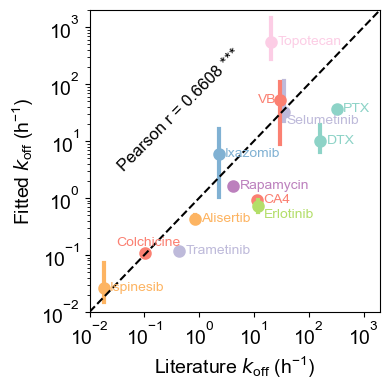

In [27]:
_, ax = plt.subplots(figsize=(4, 4))
sns.set_palette(colors)
# sns.scatterplot(
#     data=params_df, x="koff_true", y="koff", hue="Drug", ax=ax, legend=False, marker="s"
# )
sns.pointplot(
    data=params_df_with_bs,
    x="koff_true",
    y="koff_bs",
    hue="Drug",
    ax=ax,
    log_scale=True,
    native_scale=True,
    linestyle="none",
    errorbar=("pi", 50),
    legend=False,
    markersize=7,
    err_kws={"linewidth": 3},
    estimator=np.median,
)
r = pearsonr(np.log(params_df_with_bs.koff_true), np.log(params_df_with_bs.koff_bs))
print(r[1])
ax.text(0.03, 3, f"Pearson r = {r[0]:.4f} ***", fontsize=12, ha="left", rotation=45)
ax.set_yscale("log")
ax.set_xscale("log")
xlim = [1e-2, 2000]
ylim = [1e-2, 2000]
ax.plot(xlim, ylim, color="k", ls="--")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(r"Literature $k_{\mathrm{off}}\;(\mathrm{h}^{-1})$")
ax.set_ylabel(r"Fitted $k_{\mathrm{off}}\;(\mathrm{h}^{-1})$")
ticks = [1e-2, 1e-1, 1, 1e1, 1e2, 1e3]
ax.set_xticks(ticks)
ax.set_yticks(ticks)


for i, drug in enumerate(drugs):
    x0 = params_df_with_bs[params_df_with_bs.Drug == drug].koff_true.median()
    y0 = params_df_with_bs[params_df_with_bs.Drug == drug].koff_bs.median()
    if drug == "VB":
        ax.text(x0 * 0.4, y0, drug, color=colors[i], ha="left", va="center")
    elif drug == "Colchicine":
        ax.text(x0 * 0.3, y0 * 1.5, drug, color=colors[i], ha="left", va="center")
    elif drug == "Erlotinib":
        ax.text(x0 * 1.3, y0 * 0.7, drug, color=colors[i], ha="left", va="center")
    elif drug == "Selumetinib":
        ax.text(x0 * 1.1, y0 * 0.7, drug, color=colors[i], ha="left", va="center")
    else:
        ax.text(x0 * 1.3, y0, drug, color=colors[i], ha="left", va="center")
save_fig("fig3-koff", fmt="png", dpi=300)

## m

3.673695375433341e-120
Saving figure fig3-m


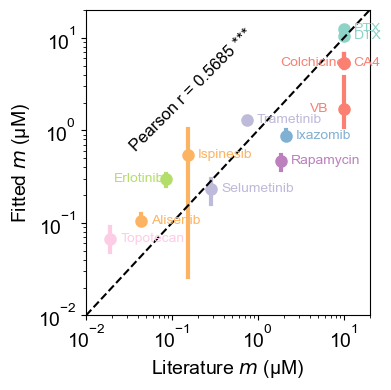

In [28]:
_, ax = plt.subplots(figsize=(4, 4))
sns.set_palette(colors)
# sns.scatterplot(
#     data=params_df, x="target", y="m", hue="Drug", ax=ax, legend=False, marker="s"
# )
sns.pointplot(
    data=params_df_with_bs,
    x="target",
    y="m_bs",
    hue="Drug",
    ax=ax,
    log_scale=True,
    native_scale=True,
    linestyle="none",
    errorbar=("pi", 50),
    legend=False,
    markersize=7,
    estimator=np.median,
    err_kws={"linewidth": 3},
)
r = pearsonr(np.log(params_df_with_bs.target), np.log(params_df_with_bs.m_bs))
print(r[1])
ax.text(0.03, 0.6, f"Pearson r = {r[0]:.4f} ***", fontsize=12, ha="left", rotation=45)
ax.set_yscale("log")
ax.set_xscale("log")
xlim = [1e-2, 20]
ylim = [1e-2, 20]
ax.plot(xlim, ylim, color="k", ls="--")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(r"Literature $m$ (μM)")
ax.set_ylabel(r"Fitted $m$ (μM)")
# ticks = [1e-2, 1e-1, 1, 1e1, 1e2, 1e3]
# ax.set_xticks(ticks)
# ax.set_yticks(ticks)


for i, drug in enumerate(drugs):
    x0 = params_df_with_bs[params_df_with_bs.Drug == drug].target.median()
    y0 = params_df_with_bs[params_df_with_bs.Drug == drug].m_bs.median()
    if drug == "VB":
        ax.text(x0 * 0.4, y0, drug, color=colors[i], ha="left", va="center")
    elif drug == "Colchicine":
        ax.text(x0 * 0.18, y0, drug, color=colors[i], ha="left", va="center")
    elif drug == "Erlotinib":
        ax.text(x0 * 0.25, y0, drug, color=colors[i], ha="left", va="center")
    else:
        ax.text(x0 * 1.3, y0, drug, color=colors[i], ha="left", va="center")

save_fig("fig3-m", fmt="png", dpi=300)

## Kd

2.6928720863936423e-126
Saving figure fig3-kd


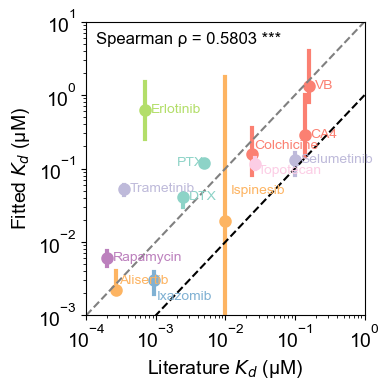

In [29]:
_, ax = plt.subplots(figsize=(4, 4))
sns.set_palette(colors)
# sns.scatterplot(
#     data=params_df, x="kd_true", y="kd", hue="Drug", ax=ax, legend=False, marker="s"
# )
sns.pointplot(
    data=params_df_with_bs,
    x="kd_true",
    y="kd_bs",
    hue="Drug",
    ax=ax,
    log_scale=True,
    native_scale=True,
    linestyle="none",
    errorbar=("pi", 50),
    legend=False,
    markersize=7,
    err_kws={"linewidth": 3},
    estimator=np.median,
)
r = spearmanr(np.log(params_df_with_bs.kd_true), np.log(params_df_with_bs.kd_bs))
print(r[1])
ax.text(
    0.003, 5, f"Spearman ρ = {r[0]:.4f} ***", fontsize=12, ha="center"
)  # , rotation=45)
ax.set_yscale("log")
ax.set_xscale("log")
xlim = [1e-4, 1]
ylim = [1e-3, 10]
ax.plot(xlim, xlim, color="k", ls="--")
ax.plot(xlim, [x * 10 for x in xlim], color="gray", ls="--")
ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(r"Literature $K_d$ (μM)")
ax.set_ylabel(r"Fitted $K_d$ (μM)")
# ticks = [1e-2, 1e-1, 1, 1e1, 1e2, 1e3]
# ax.set_xticks(ticks)
# ax.set_yticks(ticks)


for i, drug in enumerate(drugs):
    x0 = params_df_with_bs[params_df_with_bs.Drug == drug].kd_true.median()
    y0 = params_df_with_bs[params_df_with_bs.Drug == drug].kd_bs.median()
    if drug == "Ispinesib":
        ax.text(x0 * 1.2, 0.05, drug, color=colors[i], ha="left", va="center")
    elif drug == "Ixazomib":
        ax.text(x0 * 1.1, y0 * 0.6, drug, color=colors[i], ha="left", va="center")
    elif drug == "Alisertib":
        ax.text(x0 * 1.1, y0 * 1.3, drug, color=colors[i], ha="left", va="center")
    elif drug == "PTX":
        ax.text(x0 * 0.4, y0, drug, color=colors[i], ha="left", va="center")
    elif drug == "Colchicine":
        ax.text(x0 * 1.1, y0 * 1.3, drug, color=colors[i], ha="left", va="center")
    elif drug == "Topotecan":
        ax.text(x0 * 1.1, y0 * 0.8, drug, color=colors[i], ha="left", va="center")
    else:
        ax.text(x0 * 1.2, y0, drug, color=colors[i], ha="left", va="center")
save_fig("fig3-kd", fmt="png", dpi=300)

## mu

SignificanceResult(statistic=0.4077733259284398, pvalue=5.603765608123188e-57)
Saving figure fig3-mu-logp


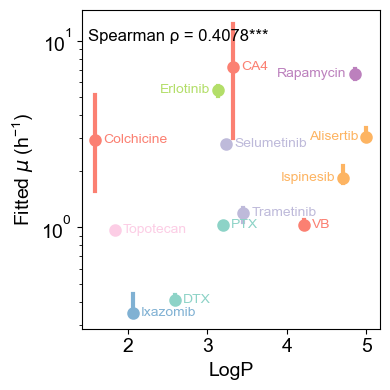

In [30]:
_, ax = plt.subplots(figsize=(4, 4))
sns.set_palette(colors)
# sns.scatterplot(
#     data=params_df, x="LogP", y="mu", hue="Drug", ax=ax, legend=False, marker="s"
# )
sns.pointplot(
    data=params_df_with_bs,
    x="LogP",
    y="mu_bs",
    hue="Drug",
    ax=ax,
    native_scale=True,
    linestyle="none",
    errorbar=("pi", 50),
    legend=False,
    estimator=np.median,
    markersize=7,
    err_kws={"linewidth": 3},
)
r = spearmanr(np.log(params_df_with_bs.LogP), np.log(params_df_with_bs.mu_bs))
print(r)
ax.text(
    1.5, 10, f"Spearman ρ = {r[0]:.4f}***", fontsize=12, ha="left"
)  # , rotation=45)
ax.set_yscale("log")
ax.set_xlabel("LogP")
ax.set_ylabel(r"Fitted $\mu\;(\mathrm{h}^{-1})$")
# ticks = [1e-2, 1e-1, 1, 1e1, 1e2, 1e3]
# ax.set_xticks(ticks)
# ax.set_yticks(ticks)


for i, drug in enumerate(drugs):
    x0 = params_df_with_bs[params_df_with_bs.Drug == drug].LogP.median()
    y0 = params_df_with_bs[params_df_with_bs.Drug == drug].mu_bs.median()
    if drug in ["Erlotinib", "Alisertib", "Ispinesib", "Rapamycin"]:
        ax.text(x0 - 0.1, y0, drug, color=colors[i], ha="right", va="center")
    else:
        ax.text(x0 + 0.1, y0, drug, color=colors[i], ha="left", va="center")

save_fig("fig3-mu-logp", fmt="png", dpi=300)

SignificanceResult(statistic=0.20205544726709843, pvalue=2.6181782486451222e-14)
Saving figure fig3-mu-fu


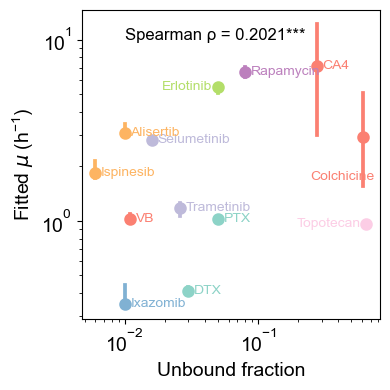

In [31]:
_, ax = plt.subplots(figsize=(4, 4))
sns.set_palette(colors)
sns.pointplot(
    data=params_df_with_bs,
    x="fu",
    y="mu_bs",
    hue="Drug",
    ax=ax,
    native_scale=True,
    linestyle="none",
    errorbar=("pi", 50),
    legend=False,
    markersize=7,
    estimator=np.median,
)
r = spearmanr(np.log(params_df_with_bs.fu), np.log(params_df_with_bs.mu_bs))
print(r)
ax.text(
    0.01, 10, f"Spearman ρ = {r[0]:.4f}***", fontsize=12, ha="left"
)  # , rotation=45)
ax.set_xscale("log")
ax.set_yscale("log")
# xlim = [1e-4, 1]
# ylim = [1e-3, 10]
# ax.plot(xlim, xlim, color="k", ls="--")
# ax.set_xlim(xlim)
# ax.set_ylim(ylim)
ax.set_xlabel("Unbound fraction")
ax.set_ylabel(r"Fitted $\mu\;(\mathrm{h}^{-1})$")
# ticks = [1e-2, 1e-1, 1, 1e1, 1e2, 1e3]
# ax.set_xticks(ticks)
# ax.set_yticks(ticks)


for i, drug in enumerate(drugs):
    x0 = params_df_with_bs[params_df_with_bs.Drug == drug].fu.median()
    y0 = params_df_with_bs[params_df_with_bs.Drug == drug].mu_bs.median()
    if drug in ["Erlotinib", "Topotecan"]:
        ax.text(x0 * 0.9, y0, drug, color=colors[i], ha="right", va="center")
    elif drug == "Colchicine":
        ax.text(x0 * 0.7, y0 * 0.6, drug, color=colors[i], ha="center", va="center")
    else:
        ax.text(x0 * 1.1, y0, drug, color=colors[i], ha="left", va="center")
save_fig("fig3-mu-fu", fmt="png", dpi=300)